# 01 — VWAP: Concepto, Cálculo y Visualización

Este notebook explica el VWAP (Volume Weighted Average Price), calcula el VWAP acumulado y móvil, y lo visualiza junto al precio y la SMA(200).

Se usan los tickers: AAPL, MSFT, SPY.

In [1]:
# Importar dependencias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from curso.lib import download_historical

pd.options.display.float_format = '{:,.6f}'.format

/Users/rolmov/Documents/github/sdd-project/.venv/lib/python3.12/site-packages/backtesting/_plotting.py:50: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support (e.g. PyCharm, Spyder IDE). Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

In [2]:
# Parámetros
TICKERS = ['AAPL', 'MSFT', 'SPY']
START = '2020-01-01'
END = '2025-12-31'
VWAP_ROLLING_WINDOW = 20
SMA_TREND = 200

In [3]:
# Descargar datos (usa cache cuando esté disponible)
data = {}
for t in TICKERS:
    try:
        df = download_historical(t, start_date=START, end_date=END)
        data[t] = df.copy()
        print(f'Descargado: {t} ->', df.shape)
    except Exception as e:
        print(f'ERROR descargando {t}: {e}')

Descargado: AAPL -> (1255, 5)
Descargado: MSFT -> (1255, 5)
Descargado: SPY -> (1255, 5)


In [4]:
# Funciones auxiliares para calcular VWAP y indicadores
def compute_vwap(df: pd.DataFrame, rolling_window: int = VWAP_ROLLING_WINDOW) -> pd.DataFrame:
    df = df.copy()
    # Normalizar nombres (esperamos Open, High, Low, Close, Volume)
    if 'Volume' not in df.columns and 'volume' in df.columns:
        df['Volume'] = df['volume']

    # Calcular precio típico
    df['typical_price'] = (df['High'] + df['Low'] + df['Close']) / 3.0

    # Manejar casos sin volumen
    if 'Volume' not in df.columns or df['Volume'].isna().all():
        df['VWAP_cumulative'] = np.nan
        df['VWAP_rolling'] = np.nan
        df['SMA_'+str(SMA_TREND)] = df['Close'].rolling(SMA_TREND).mean()
        print('Advertencia: volumen no disponible en este ticker. VWAP no calculado.')
        return df

    # Evitar division por cero: reemplazar ceros por NaN en volume temporalmente
    vol = df['Volume'].replace(0, np.nan)

    # VWAP acumulado
    df['VWAP_cumulative'] = (df['typical_price'] * vol).cumsum() / vol.cumsum()

    # VWAP rolling
    tp_vol = (df['typical_price'] * vol)
    df['VWAP_rolling'] = tp_vol.rolling(rolling_window).sum() / vol.rolling(rolling_window).sum()

    # SMA tendencia
    df['SMA_'+str(SMA_TREND)] = df['Close'].rolling(SMA_TREND).mean()

    return df

In [5]:
# Aplicar cálculos a cada ticker
for t, df in data.items():
    data[t] = compute_vwap(df)

# Mostrar resumen
for t, df in data.items():
    print('\nTicker:', t)
    display(df[['Close','Volume','typical_price','VWAP_cumulative','VWAP_rolling']].tail(3))


Ticker: AAPL


,Close,Volume,typical_price,VWAP_cumulative,VWAP_rolling
date,,,,,
2026-05-28,312.510010,48220400,311.626668,184.553130,293.494553
2026-05-29,312.059998,69982800,312.196665,184.662011,296.856287
2026-06-01,310.015015,7013934,309.815002,184.672710,298.271317



Ticker: MSFT


,Close,Volume,typical_price,VWAP_cumulative,VWAP_rolling
date,,,,,
2026-05-28,426.989990,47250500,423.049998,353.956021,415.161808
2026-05-29,450.239990,79522600,444.309987,354.175477,419.333622
2026-06-01,466.089996,13633378,463.723338,354.221074,420.468013



Ticker: SPY


,Close,Volume,typical_price,VWAP_cumulative,VWAP_rolling
date,,,,,
2026-05-28,754.599976,41562600,752.993327,497.826079,736.133920
2026-05-29,756.479980,54976100,756.416667,497.975942,738.725066
2026-06-01,755.859985,6483827,755.773336,497.993561,739.639456


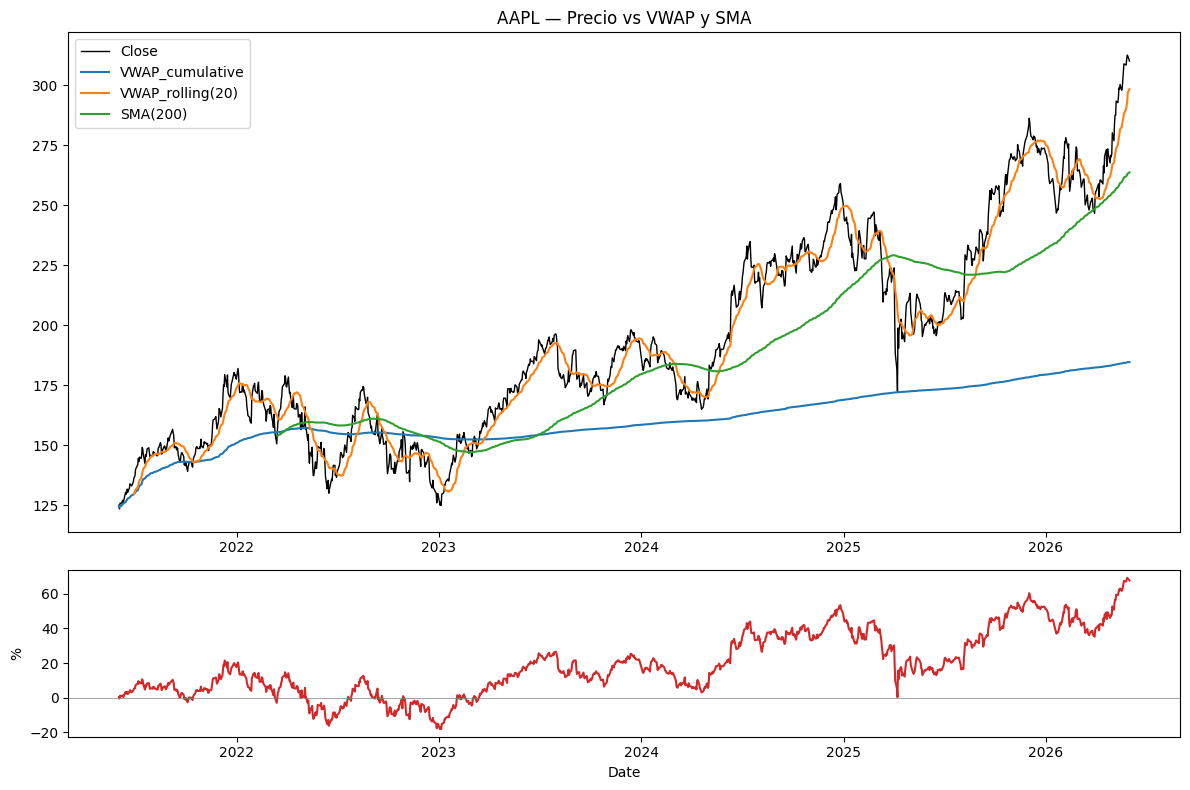

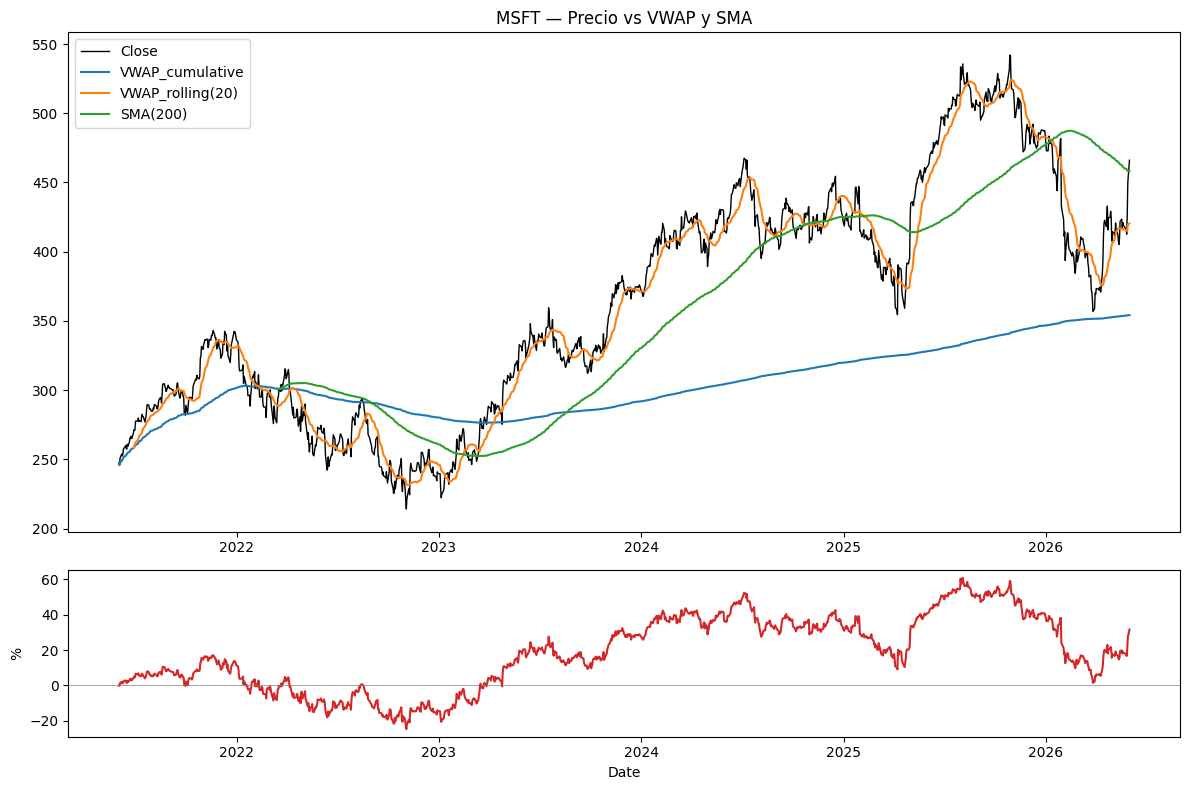

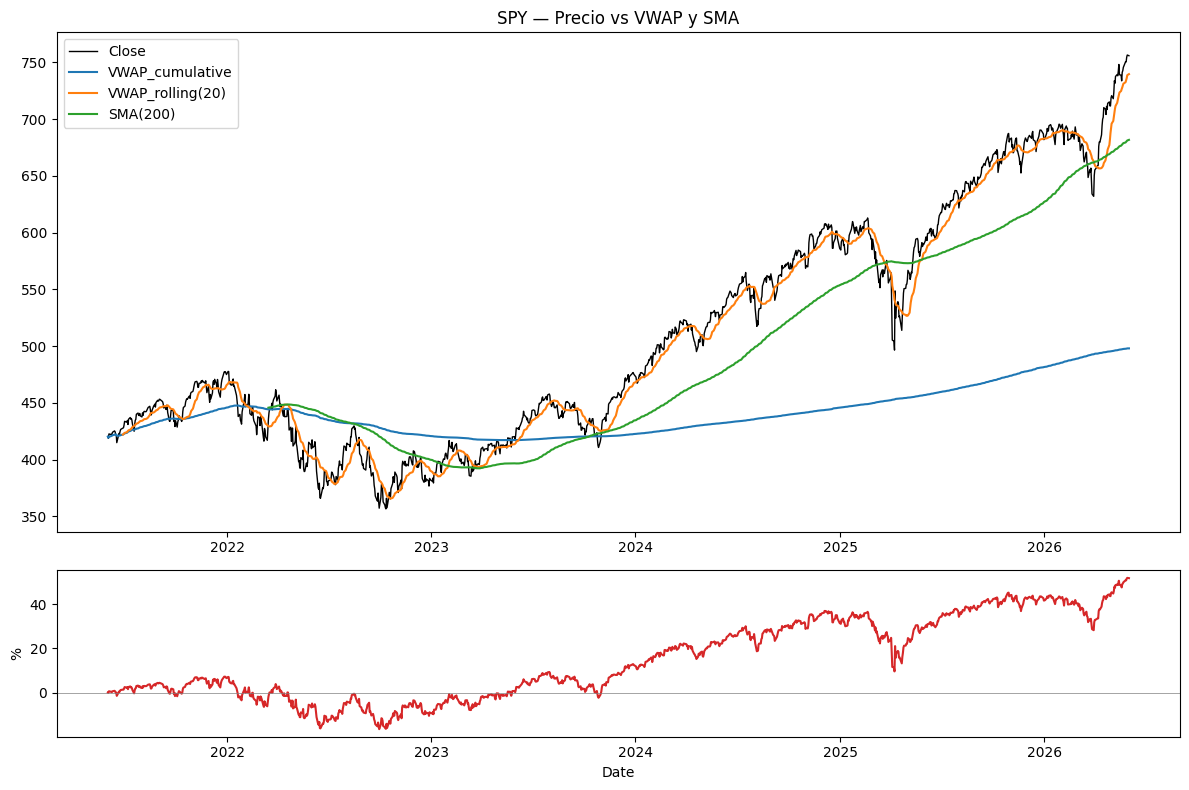

In [6]:
# Visualización: precio + VWAP acumulado + VWAP rolling + SMA200 (por ticker)
for t, df in data.items():
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios':[3,1]})
    ax1.plot(df.index, df['Close'], label='Close', color='black', linewidth=1)
    if df['VWAP_cumulative'].notna().any():
        ax1.plot(df.index, df['VWAP_cumulative'], label='VWAP_cumulative', color='tab:blue')
    if df['VWAP_rolling'].notna().any():
        ax1.plot(df.index, df['VWAP_rolling'], label=f'VWAP_rolling({VWAP_ROLLING_WINDOW})', color='tab:orange')
    if 'SMA_'+str(SMA_TREND) in df.columns:
        ax1.plot(df.index, df['SMA_'+str(SMA_TREND)], label=f'SMA({SMA_TREND})', color='tab:green')
    ax1.set_title(f'{t} — Precio vs VWAP y SMA')
    ax1.legend()

    # Divergencia porcentual (Close - VWAP) / VWAP
    if df['VWAP_cumulative'].notna().any():
        divergence = (df['Close'] - df['VWAP_cumulative']) / df['VWAP_cumulative'] * 100
        ax2.plot(df.index, divergence, label='Divergencia % (Close - VWAP_cum)', color='tab:red')
        ax2.axhline(0, color='gray', linewidth=0.5)
        ax2.set_ylabel('%')
    ax2.set_xlabel('Date')
    plt.tight_layout()
    plt.show()

In [7]:
# Estadísticas de divergencia por activo
stats = []
for t, df in data.items():
    if df['VWAP_cumulative'].notna().any():
        div = (df['Close'] - df['VWAP_cumulative']) / df['VWAP_cumulative'] * 100
        stats.append({
            'ticker': t,
            'mean_div_pct': float(div.mean()),
            'max_div_pct': float(div.max()),
            'min_div_pct': float(div.min()),
            'days_above_vwap': int((df['Close'] > df['VWAP_cumulative']).sum()),
            'days_below_vwap': int((df['Close'] < df['VWAP_cumulative']).sum()),
        })

stats_df = pd.DataFrame(stats).set_index('ticker')
display(stats_df)

,mean_div_pct,max_div_pct,min_div_pct,days_above_vwap,days_below_vwap
ticker,,,,,
AAPL,19.001452,69.333357,-18.336229,1067,188
MSFT,18.316791,60.661565,-24.620291,976,279
SPY,14.695975,51.910949,-16.537144,920,335


## Edge cases y notas de interpretación

- Si no hay datos de volumen se muestra una advertencia y no se calcula el VWAP.
- El VWAP acumulado se "arrastra" con el tiempo; en periodos largos puede envejecer — use VWAP móvil para ventanas más recientes.
- Los gaps de precio y días de bajo volumen afectan la interpretación del VWAP.